In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
from google.colab import files

print("Upload 1 of 2: throughput_scans.csv")
uploaded = files.upload()

Upload 1 of 2: throughput_scans.csv


Saving throughput_scans.csv to throughput_scans.csv


In [3]:
print("Upload 2 of 2: shifts.csv")
uploaded2 = files.upload()

Upload 2 of 2: shifts.csv


Saving shifts.csv to shifts.csv


In [4]:
# ── Load both files ───────────────────────────────────────────
scans  = pd.read_csv('throughput_scans.csv')
shifts = pd.read_csv('shifts.csv')

scans['scan_datetime'] = pd.to_datetime(scans['scan_datetime'])
shifts['shift_date']   = pd.to_datetime(shifts['shift_date'])

print(f"Throughput scans : {len(scans):,} rows")
print(f"Shifts           : {len(shifts):,} rows")

# ── Merge scans with shift info ───────────────────────────────
df = scans.merge(shifts, on='shift_id', how='left')

# ── Build features ────────────────────────────────────────────
df['hour_of_day']       = df['scan_datetime'].dt.hour
df['day_of_week']       = df['scan_datetime'].dt.dayofweek
df['month']             = df['scan_datetime'].dt.month
df['is_weekend']        = (df['day_of_week'] >= 5).astype(int)
df['is_peak_season']    = df['month'].isin([11, 12, 1]).astype(int)
df['worker_efficiency'] = (df['actual_workers'] /
                            df['planned_workers']).round(3)
df['overtime_flag']     = (df['overtime_hours'] > 0).astype(int)
df['shift_type_code']   = df['shift_type'].map(
                            {'morning': 0, 'afternoon': 1, 'night': 2})
df['scan_type_code']    = df['scan_type'].map(
                            {'receive': 0, 'sort': 1,
                             'load': 2, 'dispatch': 3})

# ── Target: units scanned per scan ───────────────────────────
df = df.dropna(subset=['units_scanned', 'actual_workers',
                        'planned_workers']).reset_index(drop=True)

print(f"\nMerged dataset   : {len(df):,} rows")
print(f"\nTarget variable (units_scanned):")
print(f"   Mean   : {df['units_scanned'].mean():.1f}")
print(f"   Median : {df['units_scanned'].median():.1f}")
print(f"   Max    : {df['units_scanned'].max()}")
print(f"   Min    : {df['units_scanned'].min()}")
print(f"\nSample:")
print(df[['shift_type','actual_workers','hour_of_day',
          'scan_type','units_scanned']].head(6).to_string())

Throughput scans : 27,048 rows
Shifts           : 3,381 rows

Merged dataset   : 27,048 rows

Target variable (units_scanned):
   Mean   : 617.2
   Median : 588.0
   Max    : 1638
   Min    : 152

Sample:
  shift_type  actual_workers  hour_of_day scan_type  units_scanned
0    morning              39            6      load            816
1    morning              39            7   receive            894
2    morning              39            8  dispatch            766
3    morning              39            9   receive            838
4    morning              39           10      sort            772
5    morning              39           11   receive            828


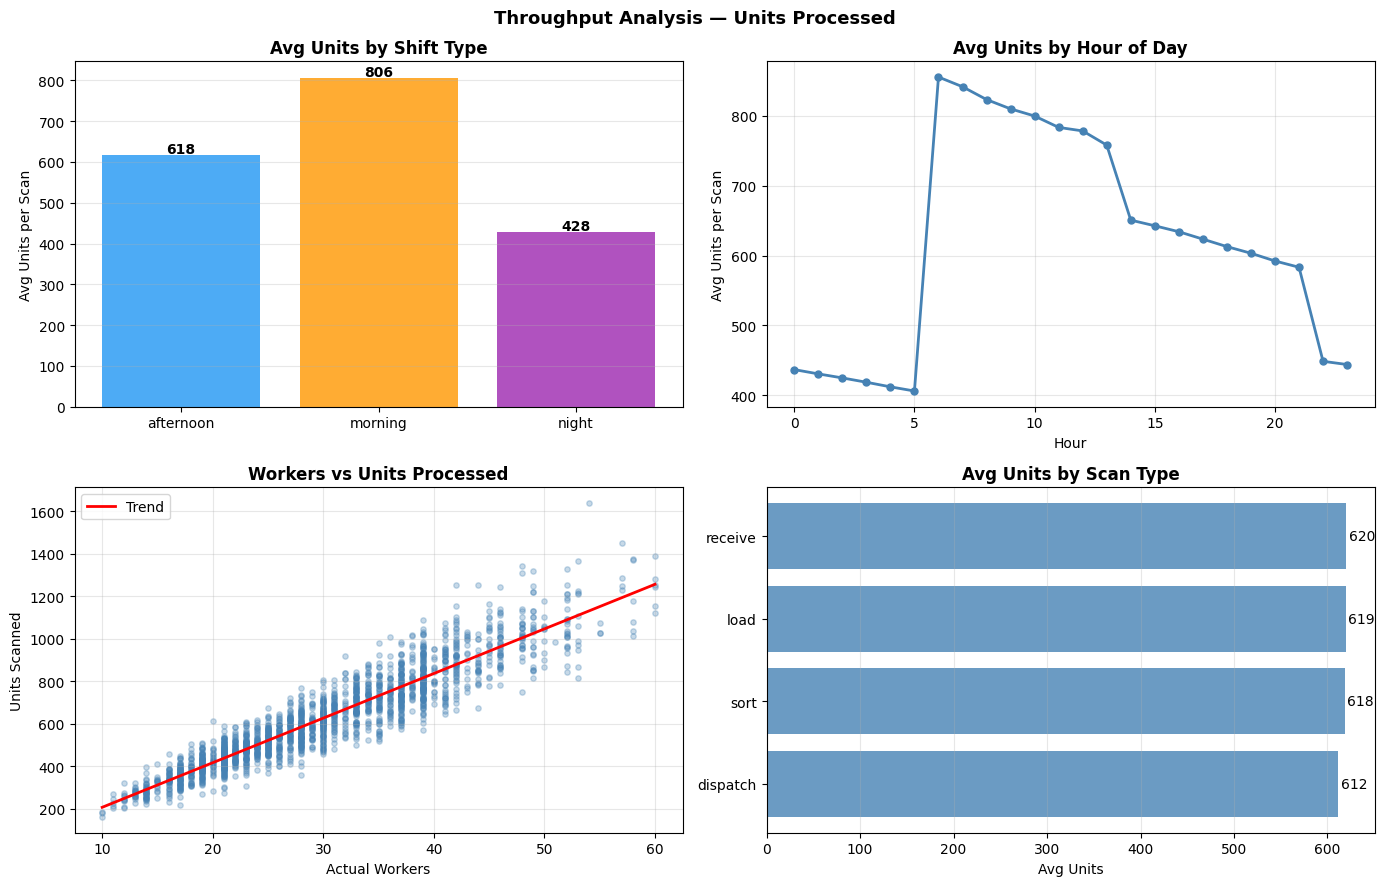

✅ Throughput patterns visualized


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Throughput Analysis — Units Processed',
             fontsize=13, fontweight='bold')

# ── Chart 1: Units by shift type ─────────────────────────────
shift_avg = df.groupby('shift_type')['units_scanned'].mean()
colors = ['#2196F3', '#FF9800', '#9C27B0']
axes[0,0].bar(shift_avg.index, shift_avg.values, color=colors, alpha=0.8)
axes[0,0].set_title('Avg Units by Shift Type', fontweight='bold')
axes[0,0].set_ylabel('Avg Units per Scan')
for i, v in enumerate(shift_avg.values):
    axes[0,0].text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold')
axes[0,0].grid(True, alpha=0.3, axis='y')

# ── Chart 2: Units by hour of day ─────────────────────────────
hour_avg = df.groupby('hour_of_day')['units_scanned'].mean()
axes[0,1].plot(hour_avg.index, hour_avg.values,
               color='steelblue', linewidth=2, marker='o', markersize=5)
axes[0,1].set_title('Avg Units by Hour of Day', fontweight='bold')
axes[0,1].set_ylabel('Avg Units per Scan')
axes[0,1].set_xlabel('Hour')
axes[0,1].grid(True, alpha=0.3)

# ── Chart 3: Workers vs Units (scatter) ───────────────────────
sample = df.sample(2000, random_state=42)
axes[1,0].scatter(sample['actual_workers'], sample['units_scanned'],
                  alpha=0.3, color='steelblue', s=15)
axes[1,0].set_title('Workers vs Units Processed', fontweight='bold')
axes[1,0].set_xlabel('Actual Workers')
axes[1,0].set_ylabel('Units Scanned')
axes[1,0].grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(sample['actual_workers'], sample['units_scanned'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['actual_workers'].min(),
                     sample['actual_workers'].max(), 100)
axes[1,0].plot(x_line, p(x_line), color='red',
               linewidth=2, label='Trend')
axes[1,0].legend()

# ── Chart 4: Units by scan type ───────────────────────────────
scan_avg = df.groupby('scan_type')['units_scanned'].mean().sort_values()
axes[1,1].barh(scan_avg.index, scan_avg.values,
               color='steelblue', alpha=0.8)
axes[1,1].set_title('Avg Units by Scan Type', fontweight='bold')
axes[1,1].set_xlabel('Avg Units')
for i, v in enumerate(scan_avg.values):
    axes[1,1].text(v + 3, i, f'{v:.0f}', va='center')
axes[1,1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('throughput_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Throughput patterns visualized")

In [6]:
# ── Define features and target ────────────────────────────────
FEATURES = [
    'actual_workers', 'planned_workers', 'worker_efficiency',
    'overtime_flag', 'hour_of_day', 'day_of_week', 'month',
    'is_weekend', 'is_peak_season', 'shift_type_code', 'scan_type_code'
]

X = df[FEATURES]
y = df['units_scanned']

# ── Train/test split ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Train : {len(X_train):,} rows")
print(f"Test  : {len(X_test):,} rows")

# ── Train 3 models ────────────────────────────────────────────
models = {
    'Linear Regression'   : LinearRegression(),
    'Random Forest'       : RandomForestRegressor(
                                n_estimators=100, max_depth=8,
                                random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingRegressor(
                                n_estimators=150, max_depth=4,
                                learning_rate=0.08, random_state=42)
}

results = {}
print("\nTraining models...")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    mae     = mean_absolute_error(y_test, y_pred)
    rmse    = mean_squared_error(y_test, y_pred) ** 0.5
    r2      = r2_score(y_test, y_pred)
    results[name] = {
        'model': model, 'y_pred': y_pred,
        'MAE': mae, 'RMSE': rmse, 'R2': r2
    }
    print(f"  ✅ {name} done")

# ── Compare results ───────────────────────────────────────────
print("\n" + "=" * 58)
print("   THROUGHPUT MODEL COMPARISON")
print("=" * 58)
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Accuracy'}")
print("-" * 58)
for name, res in results.items():
    acc = max(0, 100 - (res['MAE'] / y_test.mean() * 100))
    print(f"{name:<25} {res['MAE']:>8.1f} {res['RMSE']:>8.1f} "
          f"{res['R2']:>8.3f}   {acc:.1f}%")
print("=" * 58)

# ── Pick best model ───────────────────────────────────────────
best_name = min(results, key=lambda x: results[x]['MAE'])
best      = results[best_name]
print(f"\n🏆 Best model : {best_name}")
print(f"   MAE        : {best['MAE']:.1f} units  "
      f"(off by {best['MAE']:.0f} units per scan on average)")
print(f"   R² Score   : {best['R2']:.3f}  "
      f"({'excellent' if best['R2']>0.85 else 'good' if best['R2']>0.70 else 'moderate'})")

Train : 21,638 rows
Test  : 5,410 rows

Training models...
  ✅ Linear Regression done
  ✅ Random Forest done
  ✅ Gradient Boosting done

   THROUGHPUT MODEL COMPARISON
Model                          MAE     RMSE       R² Accuracy
----------------------------------------------------------
Linear Regression             61.3     80.9    0.864   90.1%
Random Forest                 59.7     78.4    0.872   90.4%
Gradient Boosting             59.0     77.6    0.874   90.5%

🏆 Best model : Gradient Boosting
   MAE        : 59.0 units  (off by 59 units per scan on average)
   R² Score   : 0.874  (excellent)


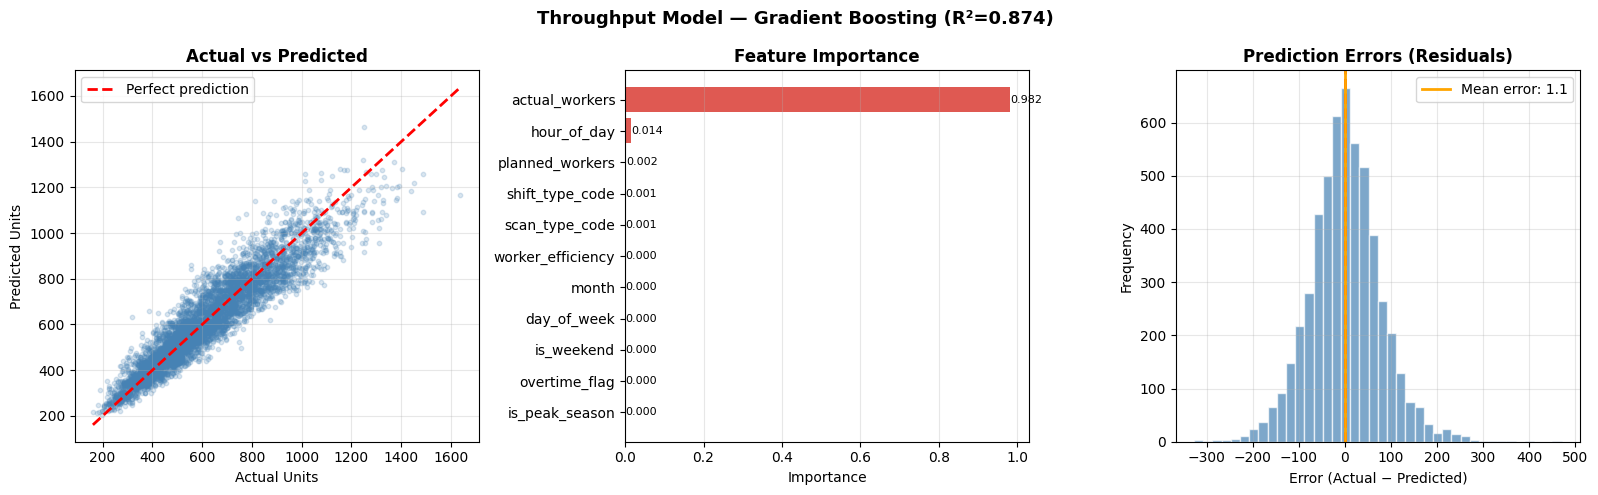

THROUGHPUT PREDICTION SCENARIOS
Workers    Shift        Hour     Predicted Units
------------------------------------------------------------
15         morning      8           316 units  ⬇
25         morning      8           526 units  =
40         morning      8           850 units  ⬆
40         morning      10          821 units  ⬆
40         afternoon    15          862 units  ⬆
20         night        22          444 units  ⬇
10         night        23          234 units  ⬇

✅ Model 3 (Throughput Regression) COMPLETE
   R² = 0.874 — model explains 87.4% of throughput variance
   Business use: predict shift output before it starts
   Decision: if predicted < target → add workers or extend shift


In [7]:
best_model  = results['Gradient Boosting']['model']
y_pred_best = results['Gradient Boosting']['y_pred']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Throughput Model — Gradient Boosting (R²=0.874)',
             fontsize=13, fontweight='bold')

# ── Chart 1: Actual vs Predicted ─────────────────────────────
axes[0].scatter(y_test, y_pred_best,
                alpha=0.2, color='steelblue', s=10)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].set_xlabel('Actual Units')
axes[0].set_ylabel('Predicted Units')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Chart 2: Feature Importance ───────────────────────────────
feat_imp = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=True)

colors = ['#d73027' if i >= len(feat_imp)-3
          else '#4575b4' for i in range(len(feat_imp))]
axes[1].barh(feat_imp['feature'], feat_imp['importance'],
             color=colors, alpha=0.8)
axes[1].set_title('Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance')
axes[1].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(feat_imp['importance']):
    axes[1].text(v+0.001, i, f'{v:.3f}', va='center', fontsize=8)

# ── Chart 3: Residuals ────────────────────────────────────────
residuals = y_test.values - y_pred_best
axes[2].hist(residuals, bins=40, color='steelblue',
             alpha=0.7, edgecolor='white')
axes[2].axvline(0, color='red', linewidth=2, linestyle='--')
axes[2].axvline(residuals.mean(), color='orange',
                linewidth=2, label=f'Mean error: {residuals.mean():.1f}')
axes[2].set_title('Prediction Errors (Residuals)', fontweight='bold')
axes[2].set_xlabel('Error (Actual − Predicted)')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('throughput_model_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Throughput Prediction Function ────────────────────────────
def predict_throughput(workers, shift_type, hour, scan_type='sort',
                        is_weekend=0, month=6):
    shift_map = {'morning': 0, 'afternoon': 1, 'night': 2}
    scan_map  = {'receive': 0, 'sort': 1, 'load': 2, 'dispatch': 3}

    features = pd.DataFrame([{
        'actual_workers'   : workers,
        'planned_workers'  : workers,
        'worker_efficiency': 1.0,
        'overtime_flag'    : 0,
        'hour_of_day'      : hour,
        'day_of_week'      : 5 if is_weekend else 1,
        'month'            : month,
        'is_weekend'       : is_weekend,
        'is_peak_season'   : 1 if month in [11,12,1] else 0,
        'shift_type_code'  : shift_map[shift_type],
        'scan_type_code'   : scan_map[scan_type]
    }])

    predicted = best_model.predict(features)[0]
    return max(0, round(predicted))

# ── Run scenarios ─────────────────────────────────────────────
print("THROUGHPUT PREDICTION SCENARIOS")
print("=" * 60)
print(f"{'Workers':<10} {'Shift':<12} {'Hour':<8} {'Predicted Units'}")
print("-" * 60)

scenarios = [
    (15, 'morning',   8),
    (25, 'morning',   8),
    (40, 'morning',   8),
    (40, 'morning',  10),
    (40, 'afternoon', 15),
    (20, 'night',    22),
    (10, 'night',    23),
]

for workers, shift, hour in scenarios:
    pred = predict_throughput(workers, shift, hour)
    gap  = pred - predict_throughput(25, 'morning', 8)
    flag = '⬆' if gap > 50 else '⬇' if gap < -50 else '='
    print(f"{workers:<10} {shift:<12} {hour:<8} {pred:>6} units  {flag}")

print("=" * 60)
print(f"\n✅ Model 3 (Throughput Regression) COMPLETE")
print(f"   R² = 0.874 — model explains 87.4% of throughput variance")
print(f"   Business use: predict shift output before it starts")
print(f"   Decision: if predicted < target → add workers or extend shift")

In [8]:
from google.colab import files

files.download('throughput_patterns.png')
files.download('throughput_model_results.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>